# ***Projekt AI: Analiza Rotacji Pracowników (Employee Attrition)***
## *Część Analityczna Projektu*

---

# 1. **Wybór zestawu danych.**
**Zestaw danych:** IBM HR Analytics Employee Attrition & Performance (`WA_Fn-UseC_-HR-Employee-Attrition.csv`).
**Adekwatność do problemu:** Zbiór zawiera dane o 1470 pracownikach i 35 cechach opisujących ich profil demograficzny, satysfakcję z pracy, zarobki, historię zatrudnienia oraz informację o tym, czy dany pracownik odszedł z firmy (`Attrition`). Jest to klasyczny problem biznesowy z obszaru People Analytics / HR Tech, polegający na identyfikacji czynników ryzyka i przeciwdziałaniu odchodzeniu kluczowych talentów.
**Możliwość zastosowania metod AI:** 
- Dane pozwalają na zastosowanie **uczenia nadzorowanego (klasyfikacja binarna)**, gdzie cechą docelową jest `Attrition` (Zmienne: Yes/No).
- Możemy użyć zaawansowanych algorytmów takich jak Regresja Logistyczna, Drzewa Decyzyjne, Random Forest, Gradient Boosting (XGBoost/LightGBM) w celu przewidywania odejść.
- Pozwala również na analizę ważności cech (feature importance), co ma kluczowe znaczenie interpretowalne w biznesie.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Kształt zbioru danych: {df.shape}")
df.head()

Kształt zbioru danych: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 2. **Analiza zbioru danych.**
#### 2.1 **Typy zmiennych i podstawowe statystyki opisowe.**
Przeanalizujmy strukturę kolumn, typy zmiennych oraz braki w danych.

Informacje o typach danych i brakach w danych.

In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Sprawdzenie braków w danych bezpośrednio

In [5]:
missing_values = df.isnull().sum().sum()
print(f"Łączna liczba braków w danych: {missing_values}")

Łączna liczba braków w danych: 0


### Opis statystyczny zmiennych numerycznych.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


#### 2.2 **Identyfikacja kolumn stałych.**
Niektóre kolumny mogą nie wnosić żadnej informacji, jeśli mają stałą wartość dla wszystkich rekordów.

In [7]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Kolumny stałe (do usunięcia w etapie modelowania): {constant_cols}")

Kolumny stałe (do usunięcia w etapie modelowania): ['EmployeeCount', 'Over18', 'StandardHours']


#### 2.3 **Analiza korelacji ze zmienną docelową.**
Przekształćmy zmienną `Attrition` na postać binarną (0/1), aby sprawdzić jej korelację ze zmiennymi numerycznymi.

In [15]:
df['Attrition_numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df['OverTime_numeric'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]

correlations = df[numeric_cols].corr()['Attrition_numeric'].sort_values(ascending=False)

corr_table = correlations.to_frame(name='Korelacja z Attrition')


print("Korelacja cech numerycznych ze zmienną Attrition:")
display(corr_table)

Korelacja cech numerycznych ze zmienną Attrition:


,Korelacja z Attrition
Attrition_numeric,1.000000
OverTime_numeric,0.246118
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019


#### 2.4 **Wykresy i wizualizacje danych.**

 Rozkład zmiennej docelowej

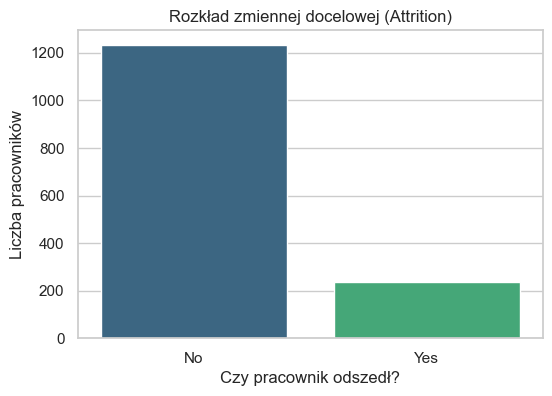

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
attrition_counts = df['Attrition'].value_counts()
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, hue=attrition_counts.index, palette='viridis', legend=False)
plt.title('Rozkład zmiennej docelowej (Attrition)')
plt.xlabel('Czy pracownik odszedł?')
plt.ylabel('Liczba pracowników')
plt.show()

Macierz korelacji kluczowych cech

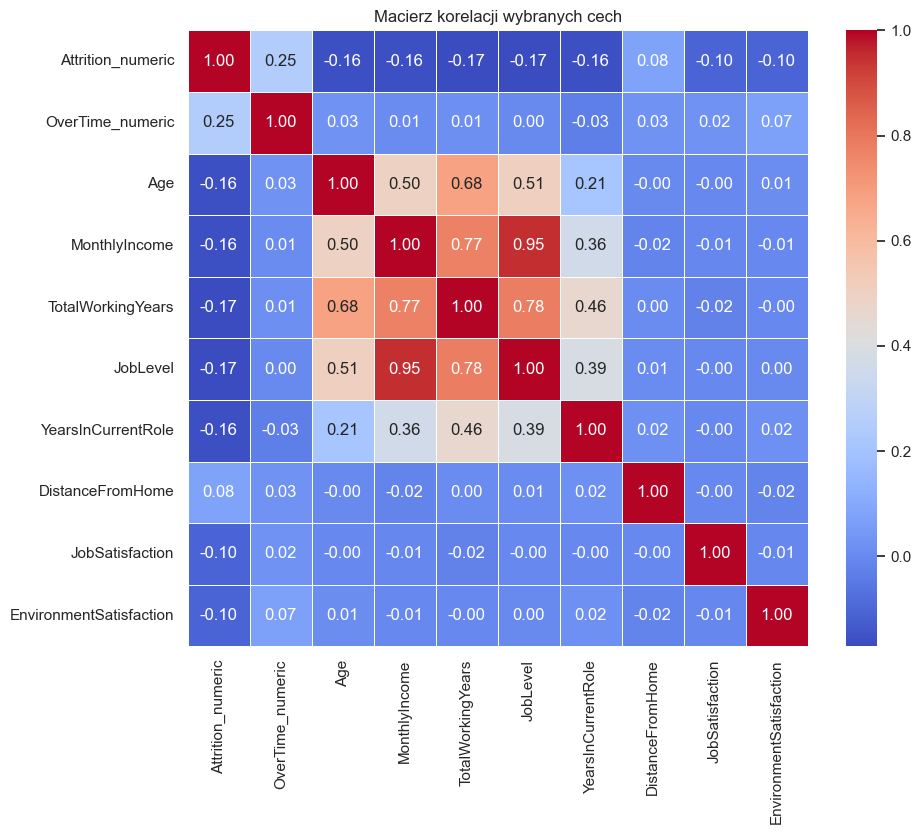

In [10]:
key_cols = ['Attrition_numeric', 'OverTime_numeric', 'Age', 'MonthlyIncome', 'TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole', 'DistanceFromHome', 'JobSatisfaction', 'EnvironmentSatisfaction']
plt.figure(figsize=(10,8))
sns.heatmap(df[key_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Macierz korelacji wybranych cech')
plt.show()

Wpływ nadgodzin na rotację

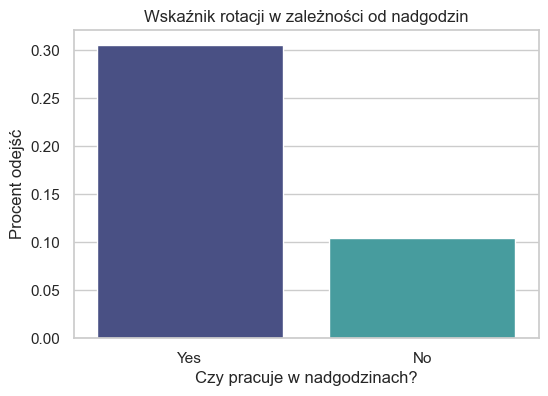

In [11]:
plt.figure(figsize=(6,4))
ot_attrition = df.groupby('OverTime')['Attrition_numeric'].mean().reset_index().sort_values(by='Attrition_numeric', ascending=False)
sns.barplot(data=ot_attrition, x='OverTime', y='Attrition_numeric', hue='OverTime', palette='mako', legend=False)
plt.title('Wskaźnik rotacji w zależności od nadgodzin')
plt.xlabel('Czy pracuje w nadgodzinach?')
plt.ylabel('Procent odejść')
plt.show()

Miesięczny dochód a rotacja

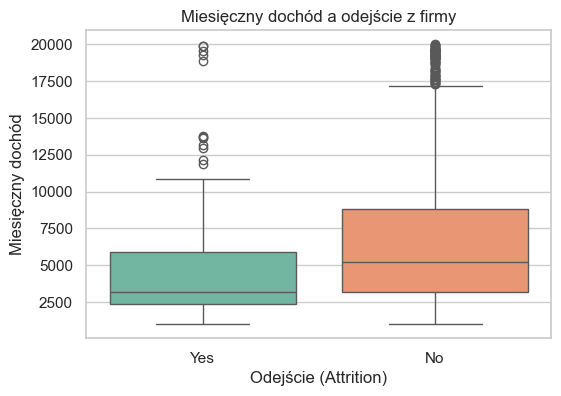

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set2', legend=False)
plt.title('Miesięczny dochód a odejście z firmy')
plt.xlabel('Odejście (Attrition)')
plt.ylabel('Miesięczny dochód')
plt.show()

### Wnioski z analizy danych:
1. **Brakujące dane:** Zbiór danych jest kompletny — zawiera 0 braków (1470 niepustych wierszy).
2. **Niezbalansowanie klas:** Zmienna docelowa jest niezbalansowana (zdecydowana większość pracowników zostaje w firmie: ~84% No, ~16% Yes). Wymaga to odpowiednich technik podczas modelowania (np. stratyfikacja, SMOTE lub dostosowanie wag klas, wybór metryki AUC-ROC).
3. **Cechy stałe:** `EmployeeCount`, `StandardHours`, `Over18` mają tylko 1 unikalną wartość i nie wnoszą wartości prognostycznej — powinny zostać usunięte przed trenowaniem modeli.
4. **Kluczowe korelacje:** Najsilniejszym pozytywnym czynnikiem skorelowanym z odejściem jest praca w nadgodzinach (`OverTime`). Najsilniejszymi negatywnymi korelacjami cechują się: `TotalWorkingYears`, `JobLevel`, `MonthlyIncome` oraz `Age` — starsi, bardziej doświadczeni pracownicy o wyższych dochodach odchodzą rzadziej.

### 3. **Sformułowanie hipotezy.**

**Hipoteza główna:**
> *Wprowadzenie modelu klasyfikacyjnego opartego na algorytmach uczenia maszynowego pozwoli na skuteczne przewidywanie ryzyka odejścia pracownika (Attrition = 'Yes') na podstawie jego cech demograficznych, finansowych i zawodowych, osiągając wynik metryki AUC-ROC powyżej 0.80, co umożliwi działowi HR wcześniejsze podjęcie działań retencyjnych wobec osób najbardziej zagrożonych odejściem.*

**Hipotezy szczegółowe (badawcze):**
1. Pracownicy pracujący w nadgodzinach (`OverTime = Yes`) charakteryzują się istotnie wyższym prawdopodobieństwem odejścia z firmy niż pracownicy bez nadgodzin.
2. Osoby o niższym dochodziem miesięcznym (`MonthlyIncome`) oraz niższym poziomie satysfakcji z pracy (`JobSatisfaction` / `EnvironmentSatisfaction`) wykazują znacznie wyższy wskaźnik rotacji.
3. Model uczenia maszynowego (np. Random Forest lub XGBoost) pozwoli na automatyczne wyekstrahowanie rankingu ważności cech, identyfikując 3 najważniejsze przyczyny rotacji w organizacji, co umożliwi optymalizację strategii HR.

### 4. **Analiza potencjalnych kandydatów na model.**

W celu zweryfikowania postawionej hipotezy głównej oraz osiągnięcia optymalnych wyników predykcyjnych, do porównania wybrano **cztery zróżnicowane algorytmy uczenia maszynowego**. Wybór ten reprezentuje różne podejścia matematyczne i architektoniczne (modele liniowe, zespoły drzewiaste oparte na baggingu oraz boostingu, a także metody geometryczne/marginesowe). 

---

#### 4.1. **Regresja Logistyczna (Logistic Regression).**
* **Sposób działania:** Jest to liniowy model klasyfikacyjny. Oblicza liniową kombinację cech wejściowych (wraz z wagami), a następnie przepuszcza uzyskany wynik przez funkcję logistyczną (sigmoidę). Wynikiem jest wartość z przedziału $(0, 1)$, interpretowana jako prawdopodobieństwo przynależności do klasy pozytywnej (`Attrition = Yes`).
* **Zalety:** Wysoce interpretowalna (wagi bezpośrednio wskazują kierunek i siłę wpływu cechy na rotację), bardzo szybka w trenowaniu i predykcji, niskie wymagania sprzętowe, łatwo aplikowalna regularyzacja (L1/L2) zapobiegająca przeuczeniu.
* **Wady:** Zakłada liniową zależność między logarytmem szans a zmiennymi objaśniającymi; słabo radzi sobie ze skomplikowanymi, nieliniowymi interakcjami bez ręcznego tworzenia cech wielomianowych. Jest wysoce wrażliwa na współliniowość cech.
* **Dopasowanie do problemu i danych:** Posłuży jako idealny model bazowy (**baseline**). Pozwoli łatwo zweryfikować proste zależności (np. wpływ nadgodzin). Wymaga jednak wcześniejszego zakodowania zmiennych kategorycznych (*One-Hot Encoding*) oraz skalowania zmiennych numerycznych ze względu na obecność cech o dużych rozpiętościach (np. `MonthlyIncome` vs `DistanceFromHome`).

#### 4.2. **Las Losowy (Random Forest Classifier).**
* **Sposób działania:** Algorytm należący do metod zespołowych (*Ensemble Learning*), wykorzystujący technikę **baggingu**. Buduje wiele niezależnych drzew decyzyjnych na losowych podpróbkach zbioru danych (próbkowanie ze zwracaniem) oraz losowych podzbiorach cech. Ostateczna decyzja podejmuje drogi głosowania większościowego (w klasyfikacji).
* **Zalety:** Bardzo wysoka odporność na przeuczenie (overfitting), brak wrażliwości na wartości odstające (outliers) i współliniowość cech (np. silną korelację między `JobLevel` a `MonthlyIncome`), automatycznie wykrywa nieliniowe interakcje między zmiennymi. Udostępnia wbudowany ranking ważności cech (*Feature Importance*).
* **Wady:** Model typu "czarna skrzynka" (utrudniona bezpośrednia interpretacja matematyczna pojedynczych reguł), może mieć tendencję do faworyzowania zmiennych ciągłych o dużej liczbie unikalnych wartości przy wyznaczaniu ważności cech.
* **Dopasowanie do problemu i danych:** Doskonale pasuje do danych tabelarycznych HR. Nie wymaga skalowania danych. Posiada wbudowany parametr `class_weight='balanced'`, co pozwala na skuteczną walkę z zaobserwowanym w sekcji 2.4 niezbalansowaniem klas (16% vs 84%) poprzez nakładanie większych kar za błędy na klasie mniejszościowej (`Yes`).

#### 4.3. **XGBoost (Extreme Gradient Boosting).**
* **Sposób działania:** Zaawansowana i zoptymalizowana implementacja algorytmu **wzmacniania gradientowego (Gradient Boosting)**. Drzewa decyzyjne budowane są sekwencyjnie (jedno po drugim), gdzie każde kolejne drzewo uczy się na błędach (resztach/residach) popełnionych przez swoich poprzedników. Proces minimalizuje zdefiniowaną funkcję straty przy użyciu optymalizacji gradientowej i jawnej regularyzacji.
* **Zalety:** Obecnie jeden z najpotężniejszych algorytmów dla danych tabelarycznych, osiągający najwyższą wydajność predykcyjną. Posiada wbudowaną regularyzację L1 i L2 zapobiegającą przeuczeniu oraz natywną obsługę asymetrii klas poprzez parametr `scale_pos_weight`.
* **Wady:** Bardzo duża liczba hiperparametrów do dostrojenia (np. `learning_rate`, `max_depth`, `subsample`), wysokie ryzyko przeuczenia w przypadku braku odpowiedniej walidacji krzyżowej i regularyzacji, wysoki koszt obliczeniowy w porównaniu do modeli liniowych.
* **Dopasowanie do problemu i danych:** Jest to główny kandydat do osiągnięcia celu biznesowego określonego w hipotezie (AUC-ROC $\ge$ 0.80). Ze względu na to, że potrafi modelować wysoce nieliniowe wzorce (np. spadek satysfakcji z pracy skorelowany z brakiem awansu w określonym czasie), idealnie nadaje się do mapowania złożonych motywacji pracowników.

#### 4.4. **Maszyna Wektorów Nośnych (Support Vector Machines - SVM).**
* **Sposób działania:** Algorytm geometryczny, który poszukuje hiperpłaszczyzny w wielowymiarowej przestrzeni cech, maksymalizującej margines separacji pomiędzy dwiema klasami. Za pomocą tzw. "triku jądrowego" (*Kernel Trick*, np. RBF) potrafi mapować dane wejściowe do przestrzeni o wyższym wymiarze, umożliwiając rozdzielenie klas nieliniowych.
* **Zalety:** Bardzo skuteczny w przestrzeniach o wysokim wymiarze (po zastosowaniu *One-Hot Encoding* liczba cech wzrośnie), odporny na zjawisko przeuczenia, decyzja opiera się wyłącznie na podzbiorze punktów treningowych (wektorach nośnych), co czyni go odpornym na szum daleko od granicy decyzyjnej.
* **Wady:** Brak bezpośredniego zwracania prawdopodobieństwa (wymaga kosztownej obliczeniowo kalibracji metodą Platta, aby uzyskać wartości do krzywej ROC), bardzo wysoka wrażliwość na brak skalowania cech, trudny w interpretacji biznesowej.
* **Dopasowanie do problemu i danych:** Wybór SVM pozwoli sprawdzić, czy problem rotacji da się efektywnie odseparować geometrycznie. Podobnie jak Regresja Logistyczna, wymaga restrykcyjnego przygotowania danych w potoku przetwarzania (*Pipeline*), w tym standaryzacji cech numerycznych. Będzie stanowił cenny punkt odniesienia dla modeli drzewiastych.